# Australia's Grid Transition

This combined notebook retains the original code and cached graphical outputs from the source analyses. Large tabular and HTML outputs are omitted; rerun the source cells with local data whenever you need the full underlying tables.

## Source notebooks
- [NEM Data – Part 1](https://github.com/accidentalscientist/daily_data_analytics_june2025/blob/main/week01_day06/nem_data_part1.ipynb)
- [NEM Data – Part 2](https://github.com/accidentalscientist/daily_data_analytics_june2025/blob/main/week01_day07/nem_data_part2.ipynb)


---

## Source section: NEM Data – Part 1


In [1]:
# import stuff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('19981201 Open Electricity.csv')

In [27]:
data.head(5)
#data.info()

In [12]:
# clean up the data
# all the columns are numeric, only datetime needs fixing
data['date'] = pd.to_datetime(data['date'])

# set the date as index
data.set_index('date', inplace=True)

## Minimal Prep

Due to the data source that we downloaded our csv from there is minimal prep work required. The only thing we had to do was set the date column to datetime format and set it as index. 

The other element to notice is the volume of columns, so below is a print out of all of them. You will notice that they essentially fall into three broad categories, that's what we'll be getting into today. 

In [16]:
for col in data.columns:
    print(col)

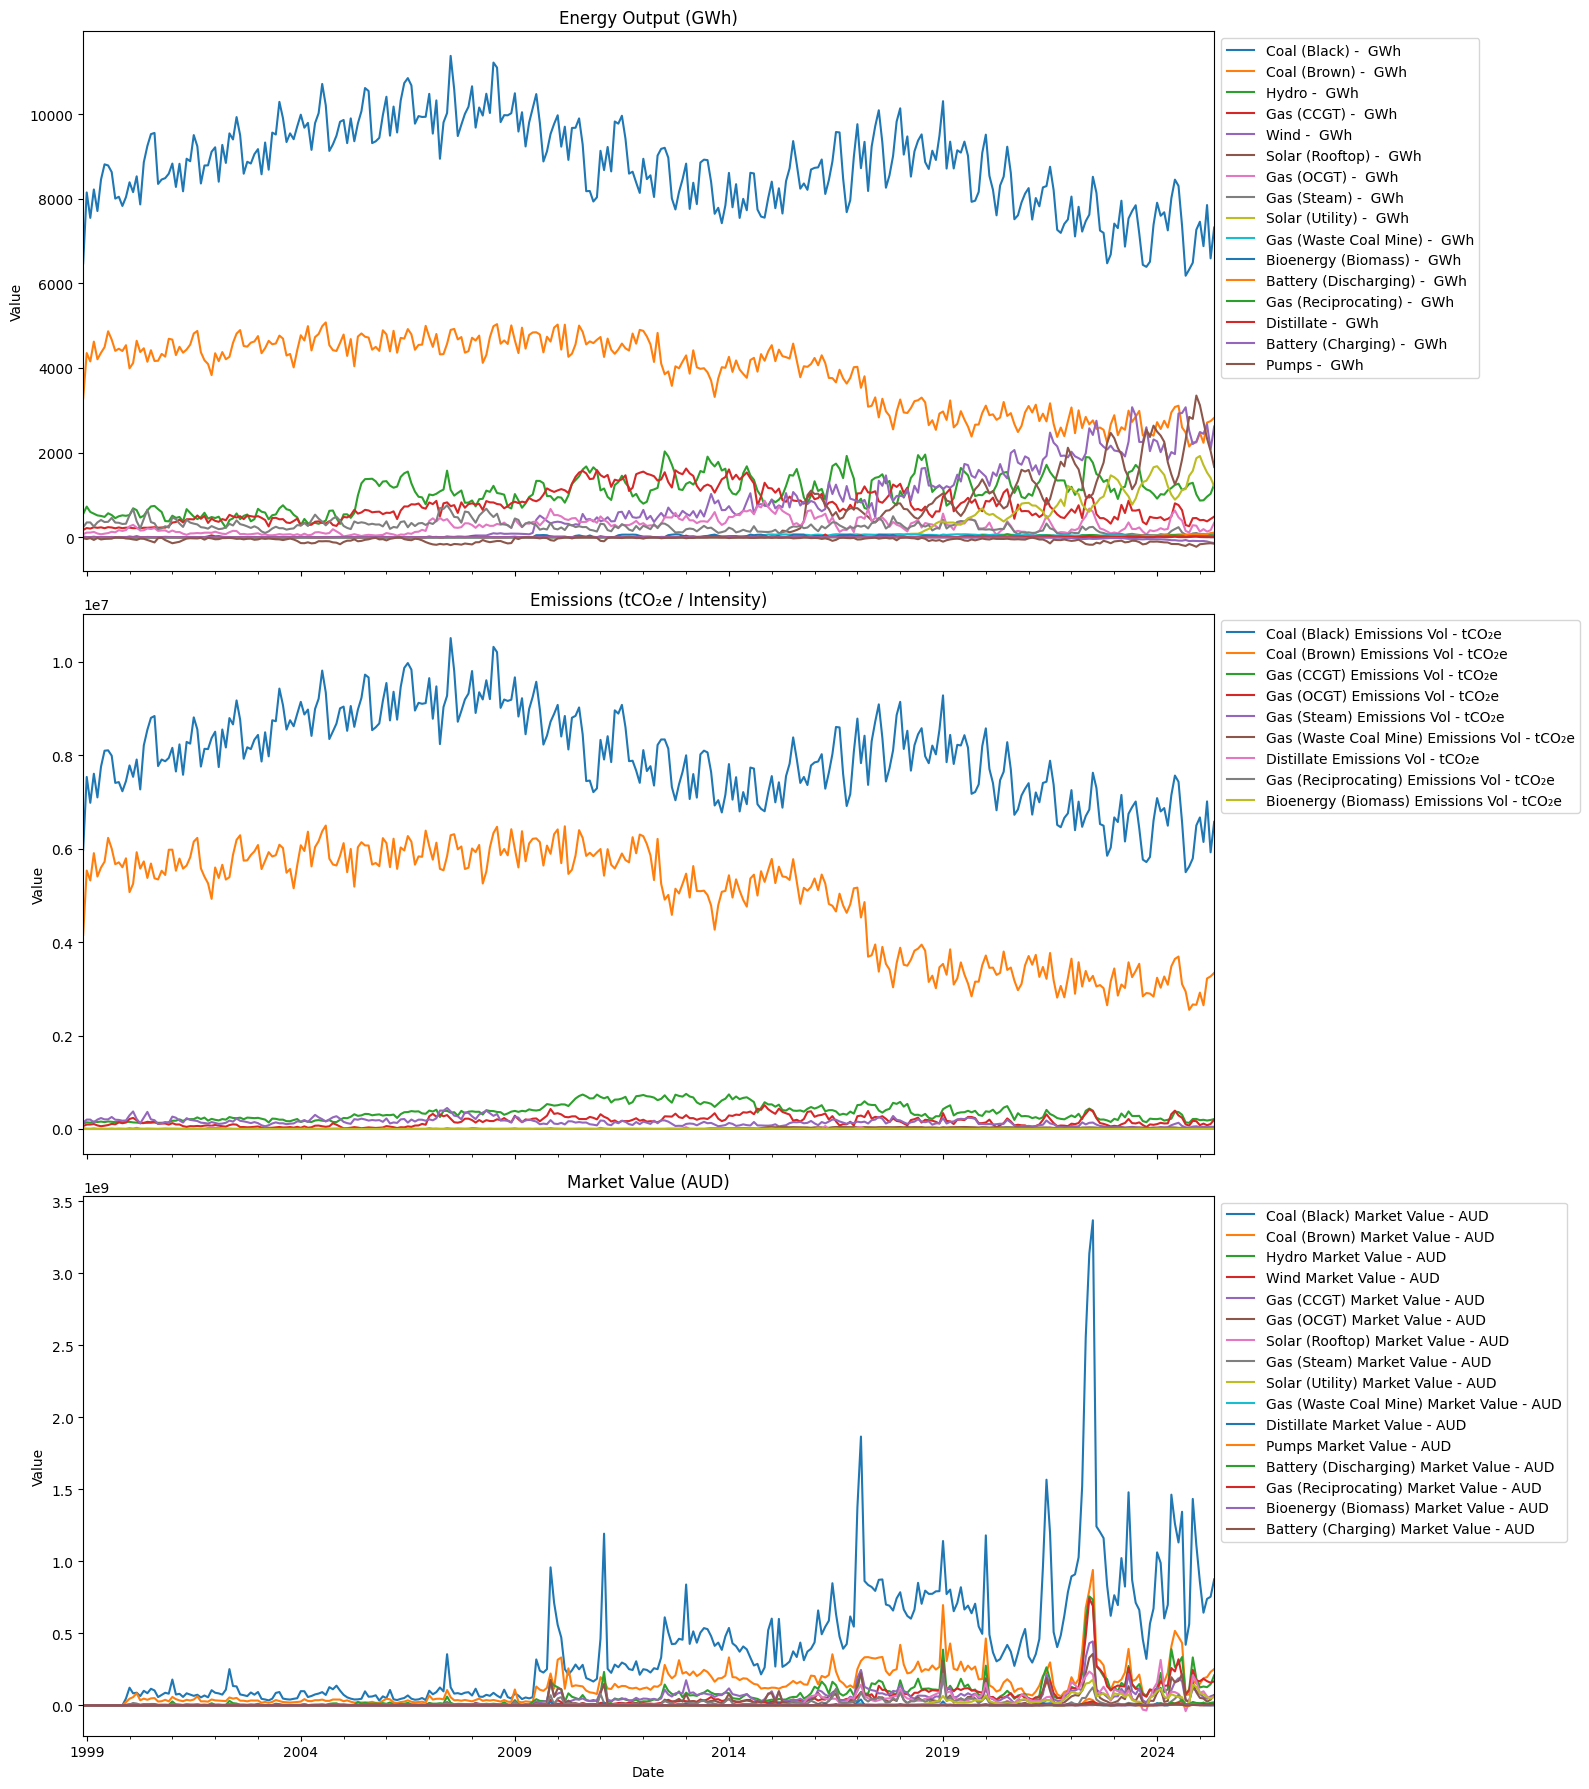

In [34]:
# let's plot groups of this data as it all appears to follow three groupings
gwh_cols = [col for col in data.columns if col.endswith("GWh")]
emissions_cols = [col for col in data.columns if col.endswith("tCO₂e")]
aud_cols = [col for col in data.columns if col.endswith("AUD")]

# sort the legend
sorted_gwh = data[gwh_cols].mean().sort_values(ascending=False).index.tolist()
sorted_emissions = data[emissions_cols].mean().sort_values(ascending=False).index.tolist()
sorted_aud = data[aud_cols].mean().sort_values(ascending=False).index.tolist()

# build the plot
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# plot the groupings
data[sorted_gwh].plot(ax=axes[0], title="Energy Output (GWh)", linewidth=1.5)
data[sorted_emissions].plot(ax=axes[1], title="Emissions (tCO₂e / Intensity)", linewidth=1.5)
data[sorted_aud].plot(ax=axes[2], title="Market Value (AUD)", linewidth=1.5)


# tidy up the plot
for ax in axes:
    ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
    ax.set_ylabel("Value")
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

## Initial Analysis of Energy Output, Emissions, and Market Value

These plots show the three core aspects of Australia's electricity market from 1998 to now. A few observations:

- Black coal dominates total energy output but is clearly declining in recent years
- Brown coal follows a similar but smaller pattern
- Renewables like wind and solar start from near zero but show dramatic growth
- Emissions directly track coal usage, which makes sense as coal has highest carbon intensity
- Market value shows more volatility than actual generation, suggesting price fluctuations play a big role

The transition from fossil fuels to renewables is visible but still in early stages. Let's dig deeper into growth rates to see how fast things are changing.

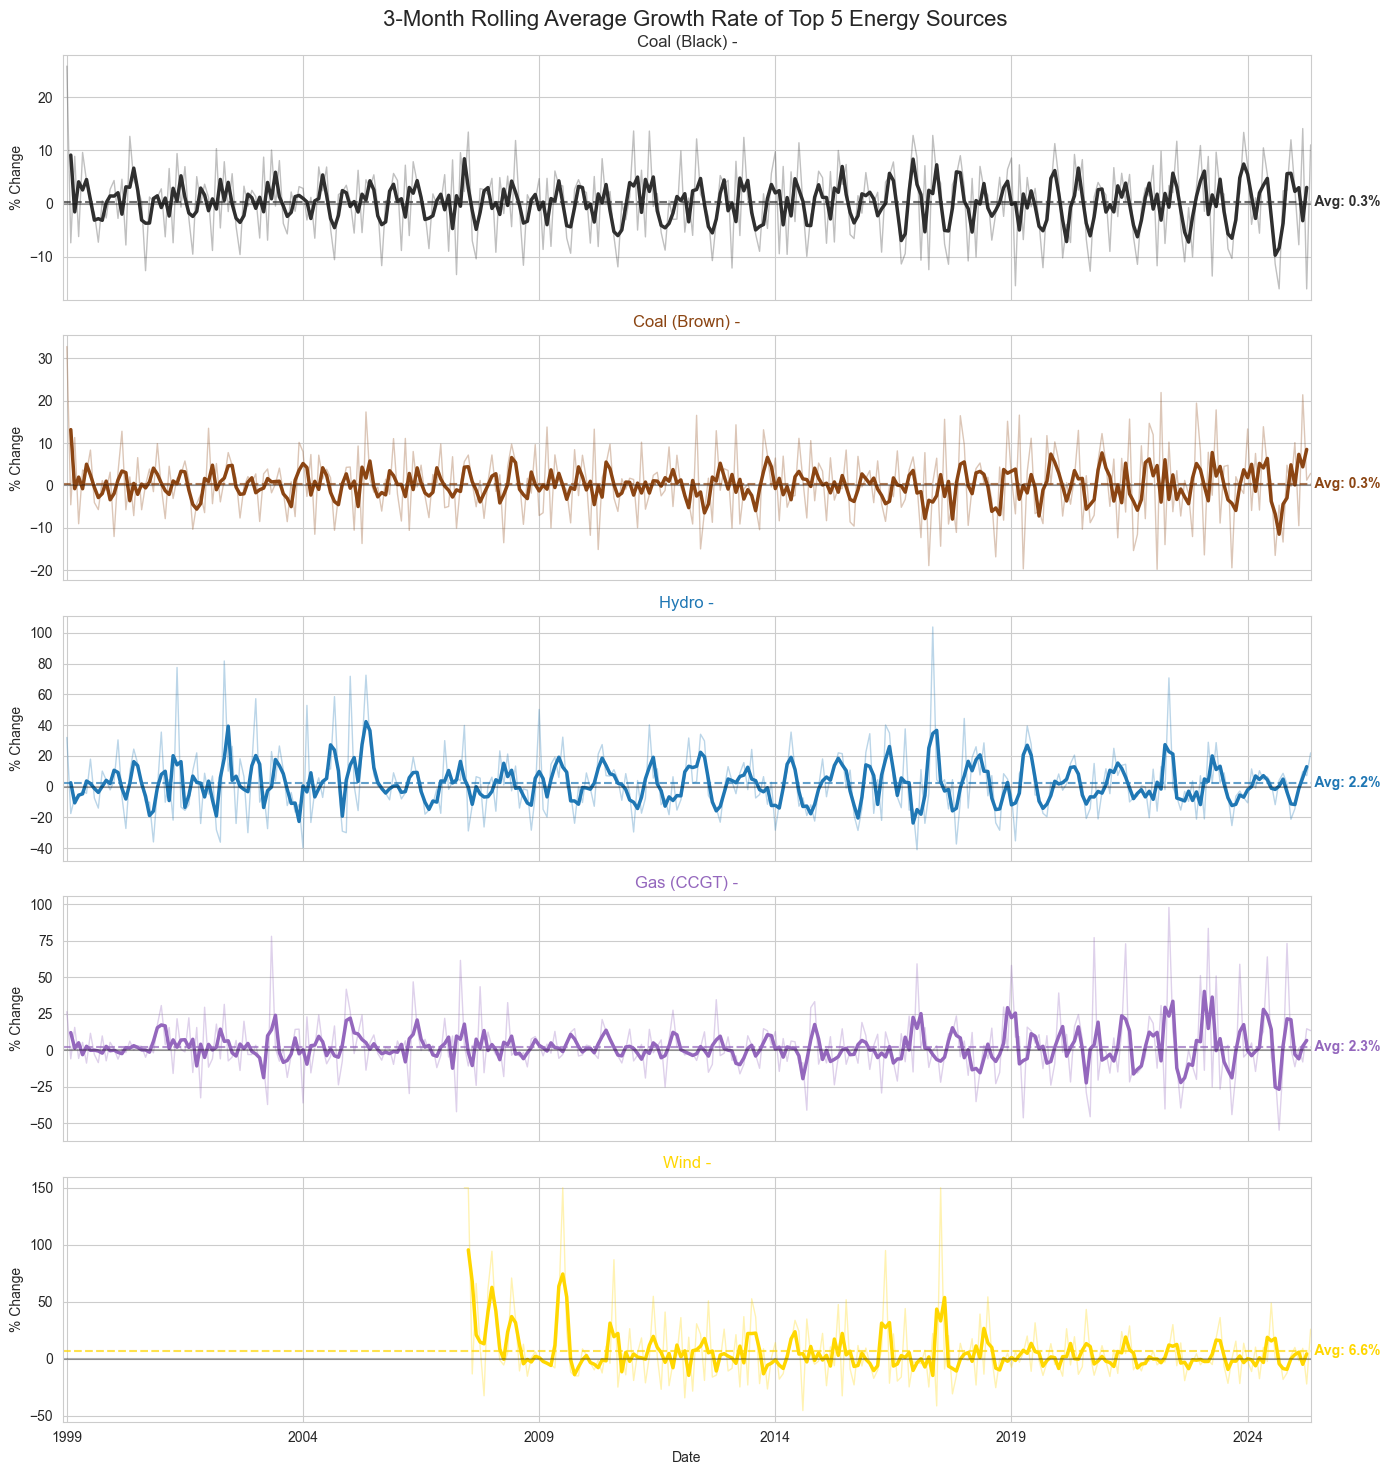

In [58]:
# let's take top 5 GWh and understand growth
top5_cols = data[gwh_cols].mean().sort_values(ascending=False).head(5).index.tolist()
data_nozero = data[top5_cols].replace(0, pd.NA)
growth = data_nozero.pct_change() * 100
growth = growth.clip(-100, 150)

# Apply 3-month rolling average for smoother trends
growth_smoothed = growth.rolling(window=3, center=True).mean()

# Define a color palette for the 5 energy sources
colors = ['#2F2F2F', '#8B4513', '#1f77b4', '#9467bd', '#FFD700']  # Blue, Orange, Green, Red, Purple

# Create a figure with 5 subplots (one for each energy source)
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)
fig.suptitle("3-Month Rolling Average Growth Rate of Top 5 Energy Sources", fontsize=16)

# Plot each energy source in its own subplot with a distinct color
for i, col in enumerate(top5_cols):
    # Plot both the raw data (lighter) and smoothed data (darker)
    growth[col].plot(ax=axes[i], linewidth=1, legend=False, color=colors[i], alpha=0.3)
    growth_smoothed[col].plot(ax=axes[i], linewidth=2.5, legend=False, color=colors[i])
    
    # Clean up the title - replace 'Coal (Black)' with 'Black' and 'Coal (Brown)' with 'Brown'
    title = col.replace('GWh', '').strip()
    title = title.replace('Coal (Black) - ', 'Black')
    title = title.replace('Coal (Brown) - ', 'Brown')
    
    axes[i].set_title(title, fontsize=12, color=colors[i])
    axes[i].set_ylabel("% Change")
    axes[i].grid(True)
    axes[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add mean growth line
    mean_growth = growth[col].mean()
    axes[i].axhline(y=mean_growth, color=colors[i], linestyle='--', alpha=0.7)
    axes[i].text(growth.index[-1], mean_growth, f' Avg: {mean_growth:.1f}%', 
                 verticalalignment='center', color=colors[i], fontweight='bold')

# Set the xlabel only for the bottom subplot
axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## Growth Rate Analysis

The growth plots reveal the change velocity of our top 5 energy sources:

- Black coal: steady negative growth, accelerating downward in recent periods - this is the clearest trend
- Brown coal: similar decline but more erratic and with periods of stabilization
- Blue energy (hydro): relatively stable with minimal growth - interesting given climate impacts on water availability
- Gas source shows the most volatile growth - likely wind or solar, with huge spikes during deployment phases
- Wind: consistently positive growth but with seasonal fluctuations and a much later starting point than the others, but consistently higher growth rate. 

The smoothed 3-month average helps cut through noise while keeping the overall trends visible. Black coal's decline seems unstoppable at this point, with the gap being filled by the more erratic renewable sources. The transition is clearly happening, but with different velocity across source types.

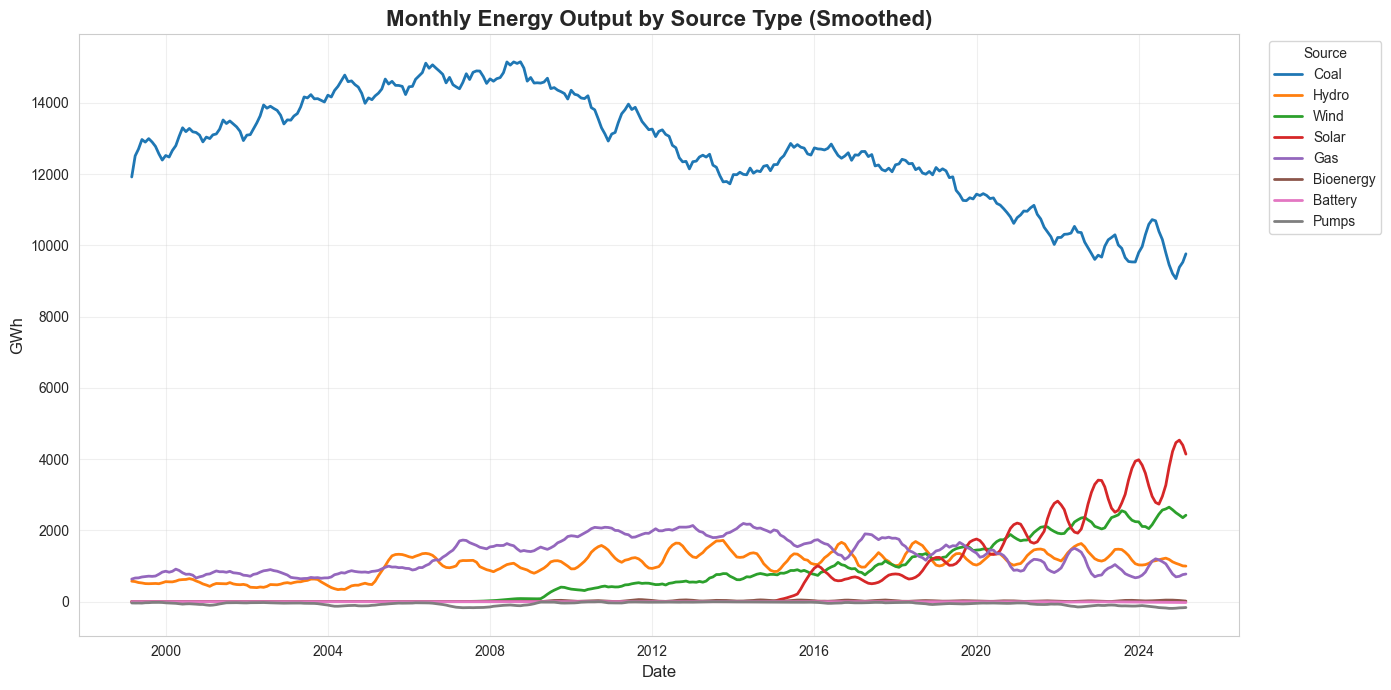

In [48]:
group_map = {
    "Coal": ["Coal (Black) -  GWh", "Coal (Brown) -  GWh"],
    "Hydro": ["Hydro -  GWh"],
    "Wind": ["Wind -  GWh"],
    "Solar": ["Solar (Rooftop) -  GWh", "Solar (Utility) -  GWh"],
    "Gas": ["Gas (CCGT) -  GWh", "Gas (OCGT) -  GWh", "Gas (Steam) -  GWh", 
            "Gas (Reciprocating) -  GWh", "Gas (Waste Coal Mine) -  GWh"],
    "Bioenergy": ["Bioenergy (Biomass) -  GWh"],
    "Battery": ["Battery (Charging) -  GWh", "Battery (Discharging) -  GWh"],
    "Pumps": ["Pumps -  GWh"]
}

# Create new grouped DataFrame
grouped = pd.DataFrame(index=data.index)
for group, cols in group_map.items():
    grouped[group] = data[cols].sum(axis=1)

# Optional smoothing
smoothed = grouped.rolling(6, center=True).mean()

# Apply seaborn style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

# Use clear color palette
colors = sns.color_palette("tab10", n_colors=len(smoothed.columns))

# Plot each line manually for color control
for i, col in enumerate(smoothed.columns):
    plt.plot(smoothed.index, smoothed[col], label=col, color=colors[i], linewidth=2)

# Labels, legend, grid
plt.title("Monthly Energy Output by Source Type (Smoothed)", fontsize=16, weight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("GWh", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Source")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Energy Source Groups Analysis

Grouping similar energy sources gives us a clearer big-picture view:

- Coal remains the dominant source but shows a clear downward trajectory since around 2018
- Gas has played a relatively stable role as a transition fuel
- Hydro provides consistent baseload renewable energy with some seasonal variations
- Wind has grown dramatically, especially since 2015, now becoming a major contributor
- Solar (combining rooftop and utility) shows the steepest growth curve of all sources
- Battery storage is just beginning to appear but will likely grow dramatically in coming years

The crossing points between different sources tell the story of Australia's energy transition. While coal still dominates, the growth trajectories suggest renewables will continue to take market share. The combined wind and solar capacity is particularly impressive, suggesting Australia's abundant natural resources are finally being harnessed effectively.

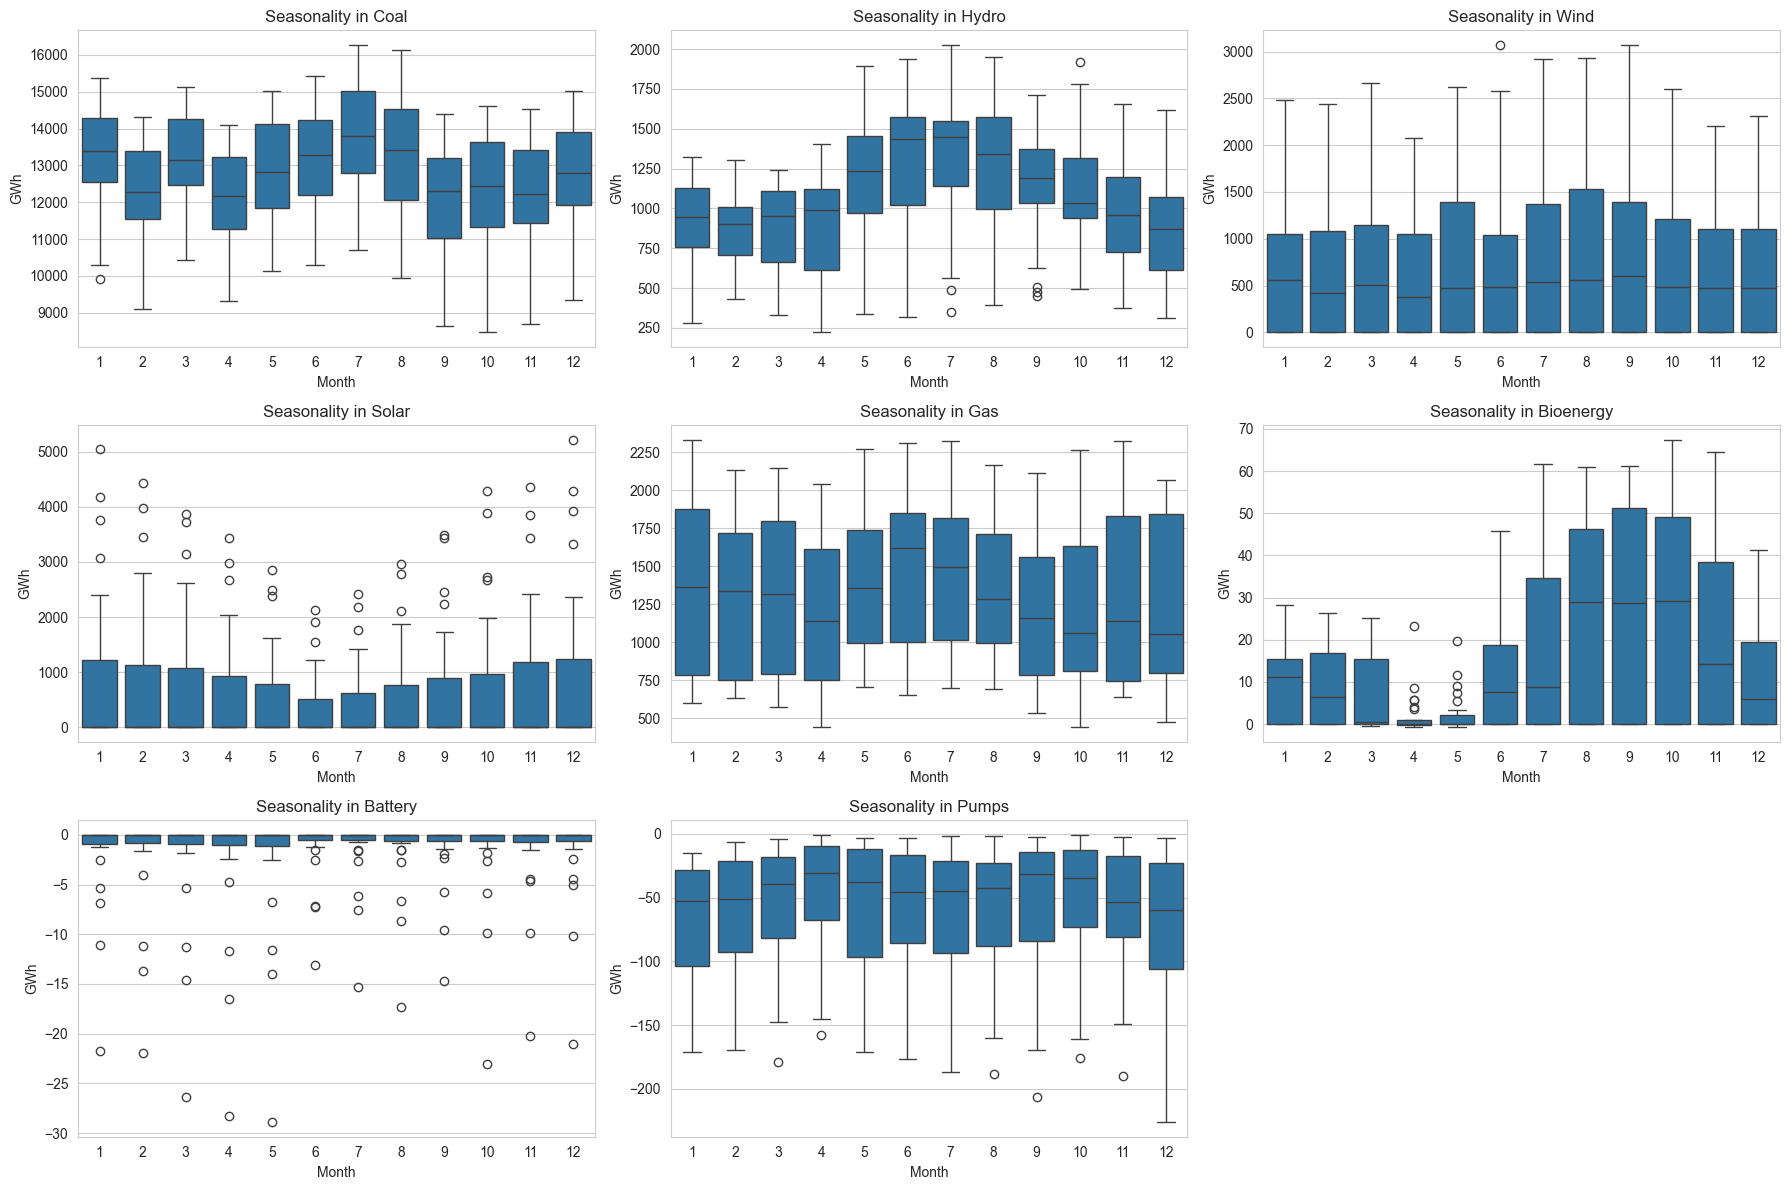

In [51]:
seasonal_df = grouped.copy()
seasonal_df["Month"] = seasonal_df.index.month

# Plot: one boxplot per group, grouped by calendar month
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(grouped.columns):
    sns.boxplot(x="Month", y=col, data=seasonal_df, ax=axes[i])
    axes[i].set_title(f"Seasonality in {col}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("GWh")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


## Seasonality Analysis

The boxplots reveal distinct seasonal patterns for each energy source:

- Coal shows the least seasonality, maintaining consistent output year-round - this makes sense as it's primarily baseload
- Solar peaks in summer months (Dec-Feb) and drops in winter (Jun-Aug), directly tracking sunlight availability
- Wind shows higher output in winter and spring months when weather systems are more active
- Hydro tends to peak in spring, likely reflecting rainfall and snowmelt patterns
- Gas shows interesting counter-cyclical patterns to renewables, suggesting its role in filling gaps

These seasonal patterns have important implications for grid management and energy storage requirements. As variable renewables take a larger share, these patterns will become increasingly important for system stability. The complementary nature of wind (higher in winter) and solar (higher in summer) is actually quite beneficial for overall system balance.

## Concluding Remarks

We can see that there is a lot to get into with this dataset. 
The volume of information shown in the first triple set of graphs displays that nicely, there are trends and topics deserving a deeper dive, that's what we did today on pure energy generation.

We can see this in the top 5 energy generation sources that we dove deeper on. The Coals are slowing having an overall growth rate of 0.3% as Hyrdo, Gas & Wind grow much more with the latter the highest at over 6%. Given that this is based off monthly-data that is pretty stark growth.

Next we went into the output of different energy groupings overall and saw a pretty stark image of Coal first reaching a peak around 2008 and before embarking on a steady decline. It's also visible how Gas and Hydro have performed steadily over the entire time period and how Wind and Solar have been small players in 2016 to substantial players today. We can also see very clearly the seasonality of Solar like a sound wave creeping up. 

This seasonality in Solar encouraged me to investigate the seasonality of all the sources and that's what our final graph does. Keep in mind there are two things happening here. First there is a seasonality to demand (winter) and hence a seasonality to generation. Second there is a seasonlity to the production capacity of renewable sources. 

## Limitations & Further Questions

A few limitations to keep in mind: We're only looking at aggregate data, so we miss regional variations which are crucial in a country as large as Australia. We also can't see how transmission constraints might be limiting renewable deployment in certain areas.

Some questions worth exploring next:
- How has the economics (AUD value) shifted between sources over time?
- What happens to grid stability metrics as renewables increase?
- How much storage would be needed to smooth out the seasonal variations?


---

## Source section: NEM Data – Part 2


In [2]:
# import stuff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('19981201 Open Electricity.csv')

In [3]:
data.head(5)
#data.info()

In [4]:
# clean up the data
# all the columns are numeric, only datetime needs fixing
data['date'] = pd.to_datetime(data['date'])

# set the date as index
data.set_index('date', inplace=True)

In [5]:
for col in data.columns:
    print(col)

## Recycle From Yesterday

As we went through yesterday, the data is in good shape and there are three broad groupings. Before diving into emission intensity and market value, let's look at how the data looks overtime. 

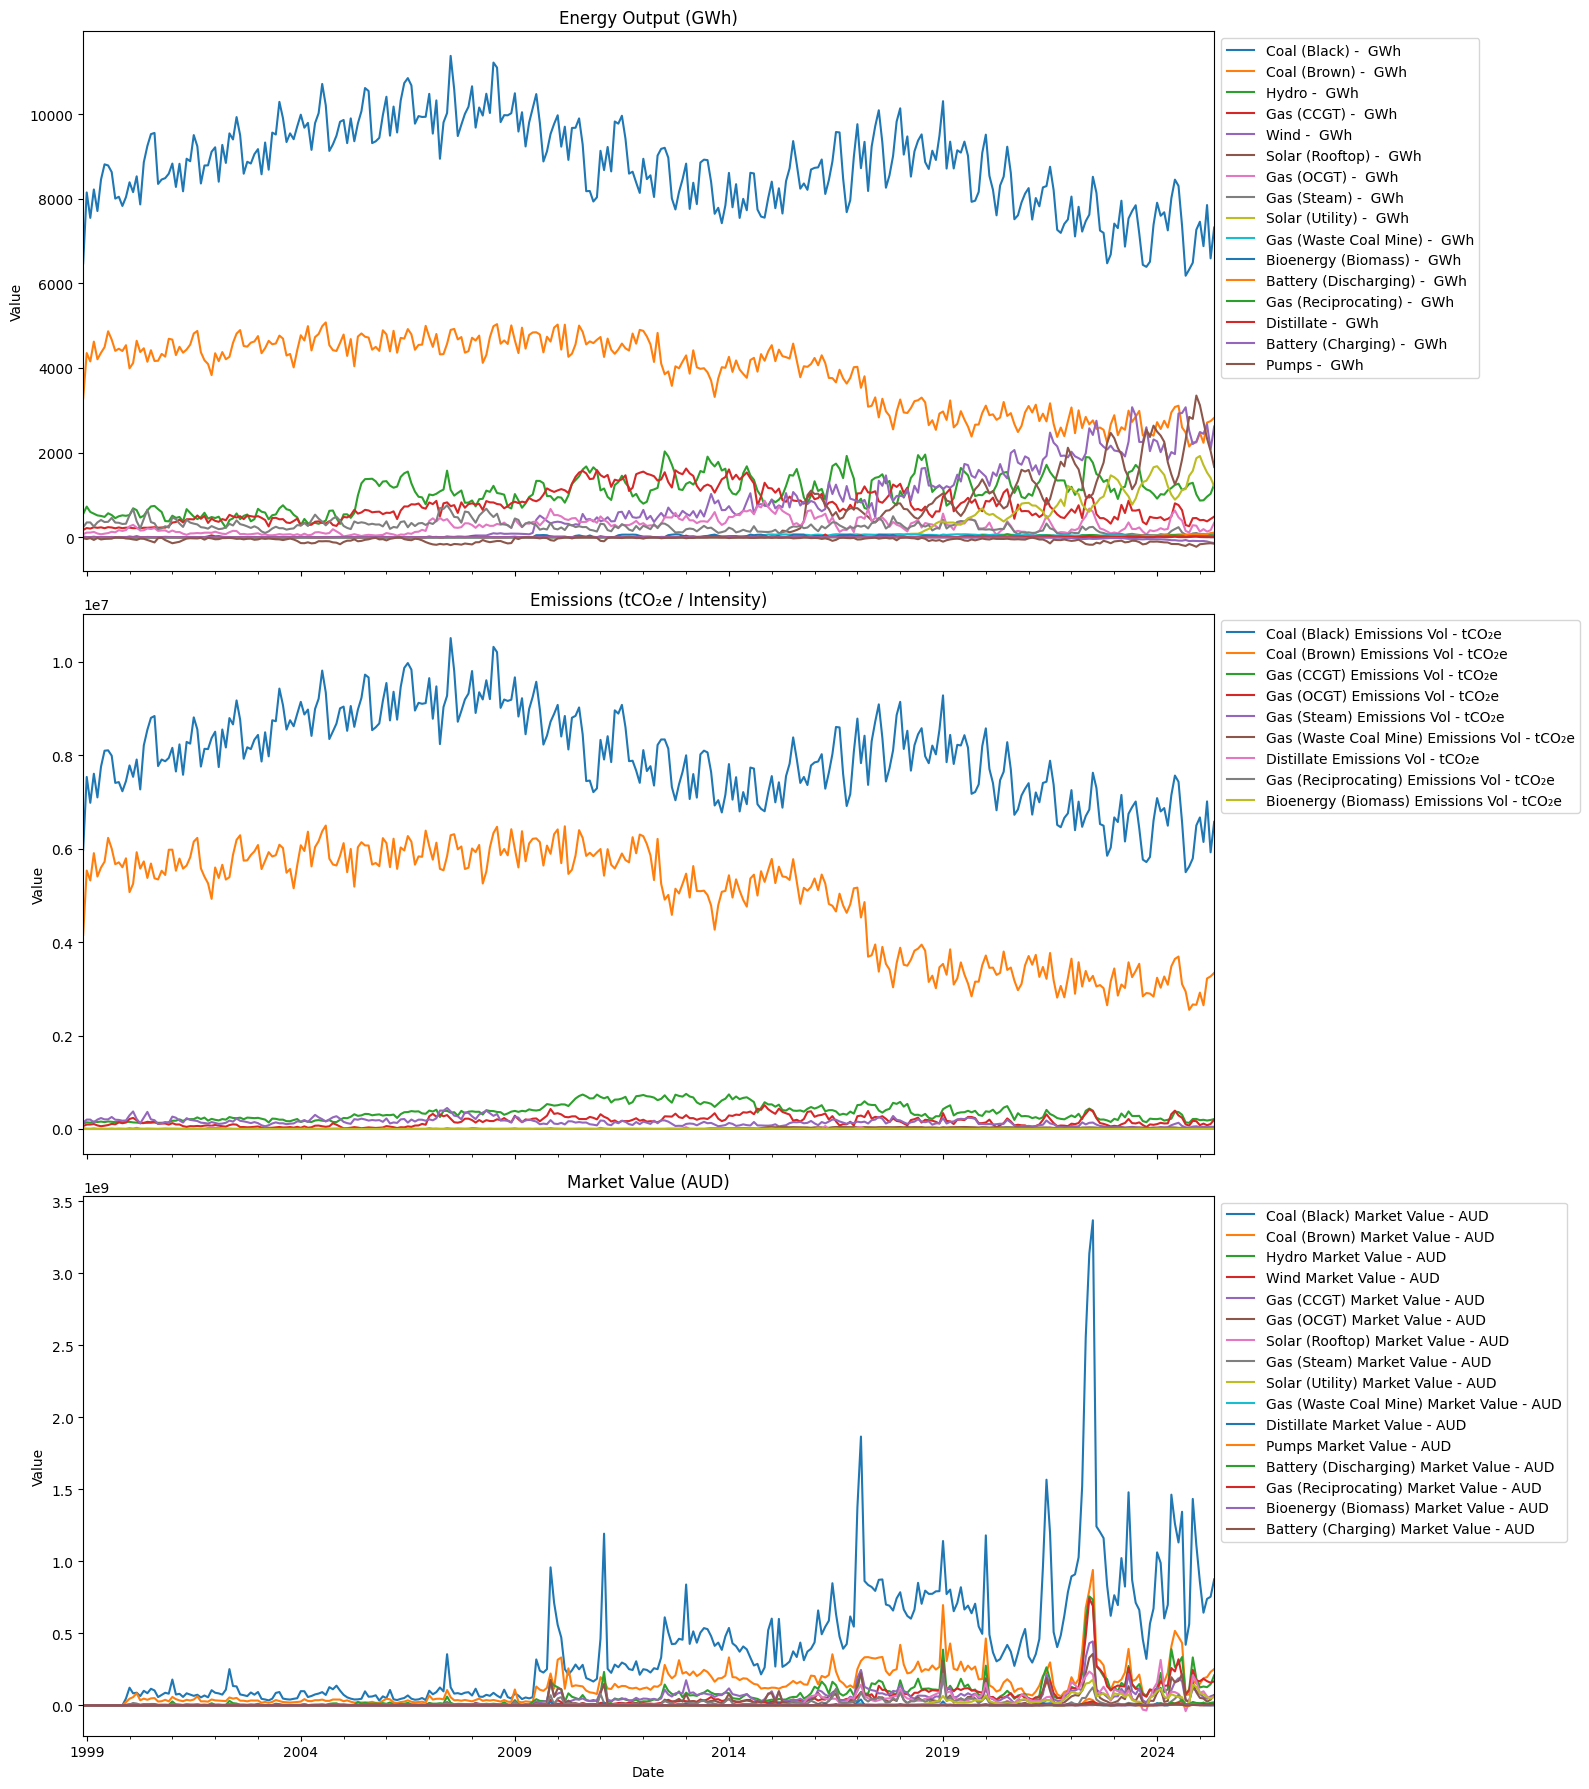

In [6]:
# let's plot groups of this data as it all appears to follow three groupings
gwh_cols = [col for col in data.columns if col.endswith("GWh")]
emissions_cols = [col for col in data.columns if col.endswith("tCO₂e")]
aud_cols = [col for col in data.columns if col.endswith("AUD")]

# sort the legend
sorted_gwh = data[gwh_cols].mean().sort_values(ascending=False).index.tolist()
sorted_emissions = data[emissions_cols].mean().sort_values(ascending=False).index.tolist()
sorted_aud = data[aud_cols].mean().sort_values(ascending=False).index.tolist()

# build the plot
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# plot the groupings
data[sorted_gwh].plot(ax=axes[0], title="Energy Output (GWh)", linewidth=1.5)
data[sorted_emissions].plot(ax=axes[1], title="Emissions (tCO₂e / Intensity)", linewidth=1.5)
data[sorted_aud].plot(ax=axes[2], title="Market Value (AUD)", linewidth=1.5)


# tidy up the plot
for ax in axes:
    ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
    ax.set_ylabel("Value")
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

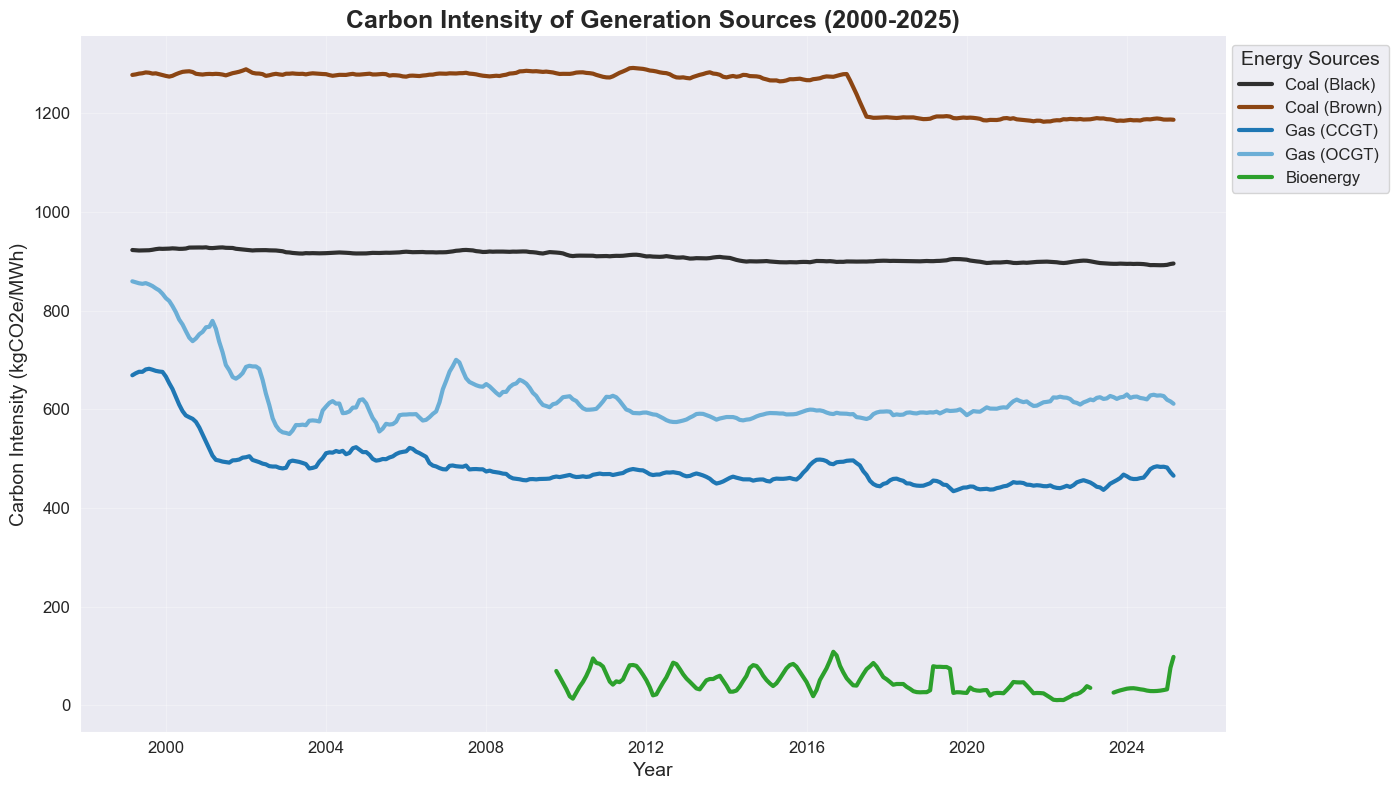

In [7]:
# 1. Define matching GWh and tCO2e columns by source
pairs = {
    "Coal (Black)": ["Coal (Black) -  GWh", "Coal (Black) Emissions Vol - tCO₂e"],
    "Coal (Brown)": ["Coal (Brown) -  GWh", "Coal (Brown) Emissions Vol - tCO₂e"],
    "Gas (CCGT)": ["Gas (CCGT) -  GWh", "Gas (CCGT) Emissions Vol - tCO₂e"],
    "Gas (OCGT)": ["Gas (OCGT) -  GWh", "Gas (OCGT) Emissions Vol - tCO₂e"],
    "Bioenergy": ["Bioenergy (Biomass) -  GWh", "Bioenergy (Biomass) Emissions Vol - tCO₂e"]
}

# 2. Compute emissions intensity in kgCO2e/MWh
intensity_df = pd.DataFrame(index=data.index)
for label, (gen_col, emi_col) in pairs.items():
    intensity_df[label] = (data[emi_col] / (data[gen_col] * 1000)) * 1000  # kgCO2e/MWh

# 3. Optional smoothing
smoothed = intensity_df.rolling(6, center=True).mean()

# 4. Plot
sns.set_style("dark")
plt.figure(figsize=(14, 8))
colors = {
    "Coal (Black)": "#2F2F2F",  # Dark gray for black coal
    "Coal (Brown)": "#8B4513",  # Brown for brown coal
    "Gas (CCGT)": "#1f77b4",    # Blue for CCGT gas
    "Gas (OCGT)": "#6baed6",    # Lighter blue for OCGT gas
    "Bioenergy": "#2ca02c"      # Green for bioenergy
}

# 6. Plot each line with custom styling
for source in smoothed.columns:
    plt.plot(smoothed.index, smoothed[source], 
             label=source, 
             color=colors[source], 
             linewidth=3)
plt.title("Carbon Intensity of Generation Sources (2000-2025)", fontsize=18, weight='bold')
plt.ylabel("Carbon Intensity (kgCO2e/MWh)", fontsize=14)
plt.xlabel("Year", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="Energy Sources", title_fontsize=14, fontsize=12, loc='upper right', bbox_to_anchor=(1.15, 1))
sns.despine()
plt.tight_layout()
plt.show()

## 🔍 Emissions Intensity: Key Observations

### 1. **Coal**
- **Brown Coal**: ~1200 kgCO₂e/MWh  
  → 🔥 Highest intensity, very carbon-heavy  
- **Black Coal**: ~900 kgCO₂e/MWh  
  → High and stable  
- Little change over time → Suggests limited fuel quality or tech improvements

---

### 2. **Gas**
- **OCGT (Open Cycle)**: ~850 → ~600  
  → Medium-high intensity, improving over time  
- **CCGT (Combined Cycle)**: ~650 → ~500  
  → Most efficient fossil fuel option  
- Shows tech-based efficiency gains

---

### 3. **Bioenergy**
- Starts very low (~100–200 kgCO₂e/MWh)  
- Highly variable → Likely due to low generation scale + inconsistent feedstock

---

## 📈 Trend Summary

| Source       | Intensity    | Trend          | Notes                                 |
|--------------|--------------|----------------|---------------------------------------|
| **Brown Coal**   | 🔥 Highest    | Flat           | Dirtiest, no major shift              |
| **Black Coal**   | High         | Slight decline | Still heavy emissions                 |
| **OCGT (Gas)**   | Medium       | Declining      | Efficiency improving                  |
| **CCGT (Gas)**   | Low–Mid      | Stable         | Best fossil fuel efficiency           |
| **Bioenergy**    | Very Low     | Noisy          | Clean but inconsistent & low volume   |

---

## 🧠 Interpretation

- **Gas (CCGT)** is the **cleanest fossil fuel** (~500 kgCO₂e/MWh)
- **Coal** remains the top emitter — especially **brown coal**
- Fuel switching from coal to gas → major climate benefit


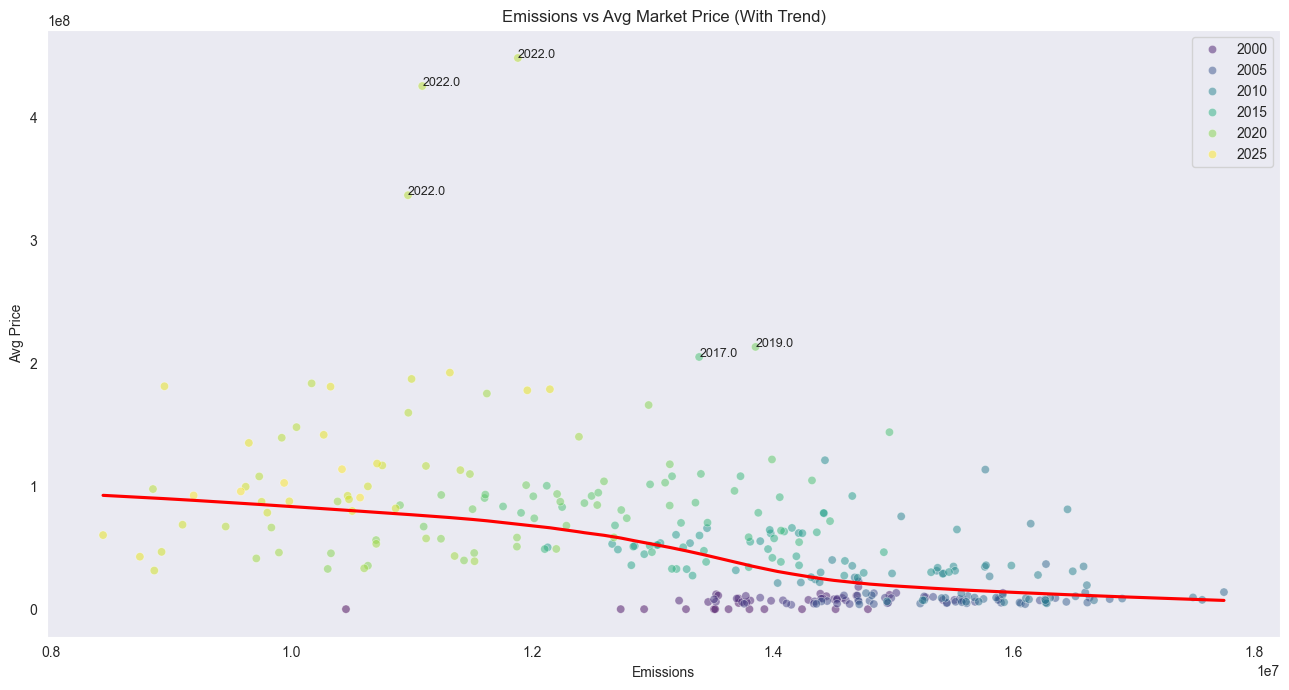

In [15]:
import statsmodels.api as sm

# Prepare long-format data
df_all = data.copy()
df_all["Year"] = df_all.index.year
df_all["Month"] = df_all.index.month
df_all["Emissions"] = data[[col for col in data.columns if col.endswith("tCO₂e")]].sum(axis=1)
df_all["Avg Price"] = data[[col for col in data.columns if col.endswith("AUD")]].mean(axis=1)

# Plot all months, all years
plt.figure(figsize=(13, 7))
sns.scatterplot(
    data=df_all,
    x="Emissions",
    y="Avg Price",
    hue="Year",
    palette="viridis",
    alpha=0.5
)

sns.regplot(
    data=df_all,
    x="Emissions",
    y="Avg Price",
    scatter=False,
    lowess=True,
    color="red",
    line_kws={"label": "LOWESS Trend"}
)
top = df_all.nlargest(5, "Avg Price")
for i, row in top.iterrows():
    plt.text(row["Emissions"], row["Avg Price"], f"{row['Year']}", fontsize=9)

plt.legend()
plt.title("Emissions vs Avg Market Price (With Trend)")
plt.tight_layout()
plt.show()



## 📊 Visualization Analysis

### Time Series Plot (Energy Output, Emissions, Market Value)

#### What it shows well:
- **Longitudinal Trends**: Clearly illustrates how each energy source has evolved over 25+ years, revealing both cyclical patterns and long-term shifts in Australia's energy landscape.
- **Source Ranking**: The sorted legend effectively shows which sources dominate in each category (GWh, emissions, market value), making it easy to identify key players.

#### What it obscures:
- **Proportional Representation**: The stacked view makes it difficult to assess the relative percentage contribution of each source to the total, especially for smaller contributors that are visually compressed at the bottom of the chart.

### Carbon Intensity Visualization

#### What it shows well:
- **Emissions Efficiency**: Directly compares the carbon intensity (kgCO₂e/MWh) across different generation technologies, clearly demonstrating the significant gap between coal and cleaner alternatives.
- **Temporal Evolution**: The smoothed time series effectively shows how carbon intensity has changed over time for each generation type, revealing technological improvements (especially in gas generation).

#### What it obscures:
- **Volume Context**: The visualization equalizes all generation sources regardless of their contribution to the total energy mix. A high-intensity but low-volume source appears equally significant to a high-volume source, potentially misrepresenting overall impact.

### Emissions vs. Market Price Scatter Plot

#### What it shows well:
- **Price-Emissions Correlation**: Effectively visualizes the relationship between total emissions and market prices, including the non-linear LOWESS trend that suggests a complex relationship.
- **Temporal Context**: The year-based color coding adds a chronological dimension that helps identify when price spikes occurred relative to emissions levels.

#### What it obscures:
- **Causality**: While correlation is visible, the plot doesn't explain whether emissions drive prices, prices drive emissions, or if both are influenced by external factors (like policy changes, technology shifts, or economic conditions).

---

## 🔑 Key Takeaways

1. **Decarbonization Progress**: Australia's electricity sector shows evidence of decarbonization, particularly through efficiency improvements in gas generation and the introduction of renewables, though coal remains a significant contributor to both generation and emissions.

2. **Price-Emissions Complexity**: The relationship between emissions and electricity prices is non-linear and has evolved over time, with recent years showing some of the highest price points despite varying emission levels, suggesting market structural changes beyond simple carbon intensity factors.

3. **Technology Differentiation**: There are stark differences in carbon intensity between generation technologies, with brown coal producing approximately 2.4 times the emissions per MWh compared to combined cycle gas (CCGT), indicating significant climate benefits from fuel switching even within fossil fuel sources.